# Why do the Starccato/VAE and BayesWave odds disagree?

This notebook audits the matched v0.44 archive without treating either classifier as ground truth. It asks four narrower questions:

1. Are the two reported odds the same statistical object?
2. Do Starccato disagreements coincide with failed NUTS diagnostics or an evidence fallback?
3. Does BayesWave's quoted thermodynamic-integration uncertainty identify unstable runs?
4. How much of the disagreement is associated with low SNR or with both BayesWave transient hypotheses losing to Gaussian noise?

**Result.** Exact equality is not expected: Starccato reports a coherent-signal versus per-detector glitch-or-noise mixture, while the archived BayesWave number is coherent signal versus glitch only; the signal/glitch waveform priors, polarization freedom, amplitude priors, and PSD treatment also differ. The VAE errors do not show failed sampler diagnostics. BayesWave does contain a separate cluster of 15 nominally native runs with implausibly tiny positive evidence errors, missed by the current zero/negative-error flag. After removing only that cluster, decision agreement is 82.1% overall but 98.8% above target SNR 40. A BayesWave signal-versus-(glitch-or-noise) diagnostic raises agreement to 86.9%, showing that hypothesis alignment explains part, but not all, of the mismatch. The injected-SNR field is a network SNR produced after normalising the H1 response to a log-uniform 10--40 draw; values above 40 are therefore expected, although two precision-screened injections have anomalously low BayesWave reconstructed-to-injected SNR ratios below 0.5.

In [1]:
from pathlib import Path
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def find_workspace(start=Path.cwd().resolve()):
    for root in (start, *start.parents):
        if (root / "paired_lno_vs_bayeswave.csv").is_file() and (root / "combined_results_nuts_morphlnz_v044.h5").is_file():
            return root
    raise FileNotFoundError("Run from the starccato_jax workspace or a child directory")

WORKSPACE = find_workspace()
PAIRED = WORKSPACE / "paired_lno_vs_bayeswave.csv"
ARCHIVE = WORKSPACE / "combined_results_nuts_morphlnz_v044.h5"
print("workspace:", WORKSPACE)
print("paired CSV:", PAIRED)
print("archive:", ARCHIVE)

workspace: /Users/avi/Documents/projects/starccato_jax
paired CSV: /Users/avi/Documents/projects/starccato_jax/paired_lno_vs_bayeswave.csv
archive: /Users/avi/Documents/projects/starccato_jax/combined_results_nuts_morphlnz_v044.h5


## Cohort contract

The paper's current precision-qualified cohort requires a native, non-recovered BayesWave result and a quoted uncertainty below 5 nats. The inspection below also exposes an unflagged, discontinuous low-error cluster rather than selecting events by their verdict.

In [2]:
raw = pd.read_csv(PAIRED)
q = raw[(raw.bw_recovered == 0) & (raw.bw_lnbf_signal_glitch_err < 5)].copy()
q["truth"] = np.where(q.cls.eq("inj_ccsn"), 1, -1)
q["vae_ok"] = q.truth * q.lno_log_odds > 0
q["bw_ok"] = q.truth * q.bw_lnbf_signal_glitch > 0
q["agree"] = np.sign(q.lno_log_odds) == np.sign(q.bw_lnbf_signal_glitch)
q["category"] = np.select(
    [q.vae_ok & q.bw_ok, q.vae_ok & ~q.bw_ok, ~q.vae_ok & q.bw_ok],
    ["both correct", "VAE only", "BayesWave only"],
    default="neither",
)

print("paired rows:", len(raw))
print("precision-qualified rows:", len(q))
display(q.groupby("cls").size().rename("n").to_frame())
display(q.category.value_counts().rename("n").to_frame())

paired rows: 1366
precision-qualified rows: 434


,n
cls,
inj_ccsn,200
real_glitch,234


,n
category,
both correct,349
VAE only,76
BayesWave only,5
neither,4


## Extract the VAE diagnostics actually used

A large NUTS \(\hat R\) is not automatically a bad final evidence here: the production code routes a failed NUTS term to nested sampling. We therefore report \(\hat R\) and divergences only for terms whose final evidence method remained MorphZ, and count nested replacements separately.

`verified` means a loud/suspect MorphZ result was cross-checked against nested sampling and differed by no more than the configured 3-nat tolerance.

In [3]:
records = {}
with h5py.File(ARCHIVE, "r") as f:
    for cls, group_name in [
        ("inj_ccsn", "lno/rn_H1_L1/inj_ccsn"),
        ("real_glitch", "lno/rn_H1_L1/real_glitch"),
    ]:
        group = f[group_name]
        for row, event_index in enumerate(group["index"][:]):
            text = group["raw_json"][row]
            if isinstance(text, bytes):
                text = text.decode()
            records[(cls, int(event_index))] = json.loads(text)

def extract_vae_diagnostics(row):
    result = records[(row.cls, int(row["index"]))]
    diagnostics = result["nuts_diagnostics"]
    status = result["evidence_status"]
    morph_terms = [name for name, item in status.items() if item["method"] == "morph"]
    nested_terms = [name for name, item in status.items() if item["method"] == "nested"]
    used_rhat = [max(diagnostics[name]["max_rhat"].values()) for name in morph_terms]
    used_divergences = sum(diagnostics[name]["divergences"] for name in morph_terms)
    glitches = result["logZ_glitch_by_detector"]
    return pd.Series({
        "vae_sg": result["logZ_signal"] - sum(glitches.values()),
        "used_max_rhat": max(used_rhat) if used_rhat else np.nan,
        "used_divergences": used_divergences,
        "nested_terms": len(nested_terms),
        "nested_due_nuts": sum(bool(status[name].get("nuts_convergence_failure")) for name in nested_terms),
        "verified_terms": sum(item["status"] == "verified" for item in status.values()),
        "evidence_failures": int(result["evidence_failures"]),
        "signal_fit_suspect": bool(result.get("signal_fit_suspect", False)),
    })

q = q.join(q.apply(extract_vae_diagnostics, axis=1))
vae_diag = q.groupby("category").agg(
    n=("index", "size"),
    median_used_max_rhat=("used_max_rhat", "median"),
    max_used_max_rhat=("used_max_rhat", "max"),
    rows_used_rhat_gt_1p01=("used_max_rhat", lambda x: int((x > 1.01).sum())),
    rows_used_rhat_gt_1p05=("used_max_rhat", lambda x: int((x > 1.05).sum())),
    rows_with_used_divergences=("used_divergences", lambda x: int((x > 0).sum())),
    rows_with_nested_term=("nested_terms", lambda x: int((x > 0).sum())),
    evidence_failures=("evidence_failures", "sum"),
)
display(vae_diag)

,n,median_used_max_rhat,max_used_max_rhat,rows_used_rhat_gt_1p01,rows_used_rhat_gt_1p05,rows_with_used_divergences,rows_with_nested_term,evidence_failures
category,,,,,,,,
BayesWave only,5,1.001445,1.013569,1,0,0,1,0
VAE only,76,1.003118,1.043915,13,0,12,24,0
both correct,349,1.003129,1.049449,80,0,50,151,0
neither,4,1.008641,1.015868,1,0,0,0,0


The disagreement group is not enriched for failed VAE diagnostics. No final MorphZ term exceeds the \(\hat R=1.05\) failure gate, and failed NUTS terms have already been replaced by nested sampling.

## BayesWave uncertainty pathology

The sorted uncertainty values have a sharp gap: 15 runs lie between \(3.2\times10^{-5}\) and \(2.4\times10^{-3}\) nat, and the next value is 0.525 nat. These are native `bayeswave_post` products and are not marked `degenerate_uncertainty`, because the current flag catches only zero or negative values. An extraordinarily small conditional TI error is not evidence of global exploration; a stuck or flat chain can look artificially precise.

In [4]:
errors = np.sort(q.bw_lnbf_signal_glitch_err.to_numpy())
print("30 smallest quoted lnBF errors:")
print(errors[:30])

# The 0.01-nat boundary lies in a >200x empty gap and is independent of class/verdict.
q["tiny_bw_error"] = q.bw_lnbf_signal_glitch_err < 0.01
q["bw_signal_vs_noise"] = q.bw_logZ_signal - q.bw_logZ_noise
q["bw_glitch_vs_noise"] = q.bw_logZ_glitch - q.bw_logZ_noise

tiny = q[q.tiny_bw_error][[
    "cls", "index", "lno_log_odds", "bw_lnbf_signal_glitch",
    "bw_lnbf_signal_glitch_err", "bw_signal_vs_noise", "bw_glitch_vs_noise",
    "bw_target_snr", "bw_reconstructed_snr_median", "vae_ok", "bw_ok",
]]
display(tiny.sort_values(["cls", "index"]))

30 smallest quoted lnBF errors:
[3.18788621e-05 4.78950557e-05 7.78492922e-05 8.32440691e-05
 1.33323838e-04 1.53240557e-04 1.59379620e-04 1.85357412e-04
 2.17377913e-04 2.46048915e-04 3.27815446e-04 4.76891048e-04
 8.32700665e-04 1.42902552e-03 2.41929820e-03 5.24870244e-01
 6.00896539e-01 6.60587565e-01 6.85940441e-01 7.70494260e-01
 7.73974038e-01 7.74701200e-01 7.79974201e-01 7.83420257e-01
 8.49587029e-01 8.53107000e-01 8.75930299e-01 9.53637777e-01
 9.64650969e-01 9.77056941e-01]


,cls,index,lno_log_odds,bw_lnbf_signal_glitch,bw_lnbf_signal_glitch_err,bw_signal_vs_noise,bw_glitch_vs_noise,bw_target_snr,bw_reconstructed_snr_median,vae_ok,bw_ok
47,inj_ccsn,83,45.704410,-38.684508,0.000032,-37.613485,1.071023,23.289835,NaN,True,False
59,inj_ccsn,108,221.003659,580.663944,0.000217,467.978074,-112.685870,27.021363,NaN,True,True
112,inj_ccsn,190,167.318993,-198.212731,0.001429,-186.996238,11.216493,29.620006,29.417500,True,False
159,inj_ccsn,288,467.271665,-1734.703737,0.000246,-928.468519,806.235218,52.702187,32.199494,True,False
347,inj_ccsn,597,253.738953,-30.541227,0.002419,163.074298,193.615525,30.805270,NaN,True,False
373,inj_ccsn,636,201.723225,-158.917164,0.000159,249.615835,408.532999,36.414922,33.462663,True,False
868,real_glitch,327,-12.262126,-266.760425,0.000083,-220.932779,45.827646,31.098900,12.029525,True,True
872,real_glitch,333,-104.729021,-89.843345,0.000833,142.780838,232.624183,30.722151,30.787990,True,True
1035,real_glitch,603,-24.005460,-135.385433,0.000133,-37.207831,98.177602,22.279940,12.280307,True,True
1063,real_glitch,645,-0.291402,-518.304007,0.000185,-952.471018,-434.167011,21.180470,11.490663,True,True


The tiny-error cluster contains both correct and incorrect classifications, so rejecting it is not verdict-based. Five of six injected CCSNe in the cluster are assigned the wrong BayesWave sign, including large-magnitude failures. These runs require independent-seed reruns; their quoted error bars are not credible convergence certificates.

## Agreement after excluding only the discontinuous error cluster

In [5]:
clean = q[~q.tiny_bw_error].copy()
clean["bw_mixture"] = clean.bw_logZ_signal - np.logaddexp(
    np.log(0.5) + clean.bw_logZ_glitch,
    np.log(0.5) + clean.bw_logZ_noise,
)
clean["mixture_agree"] = np.sign(clean.lno_log_odds) == np.sign(clean.bw_mixture)
clean["vae_sg_agree"] = np.sign(clean.vae_sg) == np.sign(clean.bw_lnbf_signal_glitch)

summary = pd.DataFrame({
    "n": [len(q), len(clean)],
    "VAE--BayesWave sign agreement": [q.agree.mean(), clean.agree.mean()],
    "VAE expected-class fraction": [q.vae_ok.mean(), clean.vae_ok.mean()],
    "BayesWave expected-class fraction": [q.bw_ok.mean(), clean.bw_ok.mean()],
}, index=["paper uncertainty cut only", "excluding tiny-error cluster"])
display(summary)

bins = [0, 10, 15, 20, 25, 30, 40, np.inf]
clean["snr_bin"] = pd.cut(clean.bw_target_snr, bins, right=False)
snr_table = clean.groupby("snr_bin", observed=True).agg(
    n=("index", "size"),
    agreement=("agree", "mean"),
    VAE_expected=("vae_ok", "mean"),
    BayesWave_expected=("bw_ok", "mean"),
)
display(snr_table)

,n,VAE--BayesWave sign agreement,VAE expected-class fraction,BayesWave expected-class fraction
paper uncertainty cut only,434,0.813364,0.979263,0.815668
excluding tiny-error cluster,419,0.821002,0.980907,0.821002


,n,agreement,VAE_expected,BayesWave_expected
snr_bin,,,,
"[0.0, 10.0)",14,0.642857,1.000000,0.642857
"[10.0, 15.0)",65,0.707692,0.969231,0.676923
"[15.0, 20.0)",64,0.671875,0.984375,0.656250
"[20.0, 25.0)",61,0.852459,0.967213,0.852459
"[25.0, 30.0)",61,0.819672,0.983607,0.836066
"[30.0, 40.0)",72,0.875000,0.986111,0.888889
"[40.0, inf)",82,0.987805,0.987805,1.000000


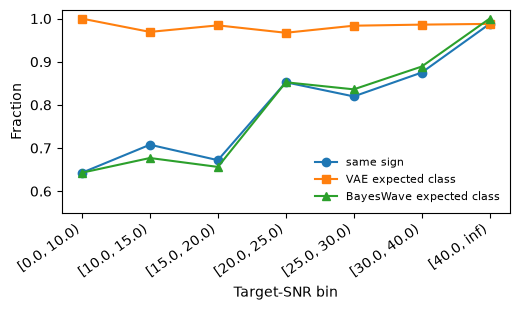

In [6]:
fig, ax = plt.subplots(figsize=(5.3, 3.2))
centres = np.arange(len(snr_table))
ax.plot(centres, snr_table.agreement, marker="o", label="same sign")
ax.plot(centres, snr_table.VAE_expected, marker="s", label="VAE expected class")
ax.plot(centres, snr_table.BayesWave_expected, marker="^", label="BayesWave expected class")
ax.set_xticks(centres, [str(x) for x in snr_table.index], rotation=35, ha="right")
ax.set_xlabel("Target-SNR bin")
ax.set_ylabel("Fraction")
ax.set_ylim(0.55, 1.02)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Above target SNR 40, the classifications agree for 81 of 82 cases. The single exception is injected CCSN 258, for which BayesWave selects signal and the VAE selects glitch. This is the cleanest model-failure case to inspect, not evidence for a population-wide sampler failure.

## Hypothesis alignment

Two useful but still imperfect alternative comparisons are:

- **VAE S/G:** remove the VAE's noise mixture and compare coherent CCSN evidence with the product of the two per-detector blip evidences.
- **BayesWave S/(G or N):** compare the BayesWave signal evidence with an equal-weight network-level mixture of its glitch and noise evidences.

Neither makes the models identical, but they show the direction and size of the hypothesis-definition effect.

In [7]:
def sign_agreement(a, b):
    return float(np.mean(np.sign(a) == np.sign(b)))

alignment = pd.DataFrame({
    "comparison": [
        "VAE BCR vs BayesWave S/G",
        "VAE S/G vs BayesWave S/G",
        "VAE BCR vs BayesWave S/(G or N)",
    ],
    "sign agreement": [
        sign_agreement(clean.lno_log_odds, clean.bw_lnbf_signal_glitch),
        sign_agreement(clean.vae_sg, clean.bw_lnbf_signal_glitch),
        sign_agreement(clean.lno_log_odds, clean.bw_mixture),
    ],
    "Spearman rho": [
        spearmanr(clean.lno_log_odds, clean.bw_lnbf_signal_glitch).statistic,
        spearmanr(clean.vae_sg, clean.bw_lnbf_signal_glitch).statistic,
        spearmanr(clean.lno_log_odds, clean.bw_mixture).statistic,
    ],
})
display(alignment)

before = np.sign(clean.lno_log_odds) == np.sign(clean.bw_lnbf_signal_glitch)
after = np.sign(clean.lno_log_odds) == np.sign(clean.bw_mixture)
display(pd.crosstab(before, after, rownames=["S/G agrees"], colnames=["S/(G or N) agrees"]))

,comparison,sign agreement,Spearman rho
0,VAE BCR vs BayesWave S/G,0.821002,0.727690
1,VAE S/G vs BayesWave S/G,0.816229,0.727638
2,VAE BCR vs BayesWave S/(G or N),0.868735,0.699841


S/(G or N) agrees,False,True
S/G agrees,,
False,53,22
True,2,342


Adding BayesWave's noise hypothesis resolves 22 original sign disagreements and creates 2 new ones (a net reduction from 75 to 55). The remaining mismatch is expected from the different waveform priors and likelihood contracts: a 5-dimensional CCSN decoder versus a trans-dimensional coherent wavelet model, a 5-dimensional blip decoder versus independent wavelet glitches, fixed linear polarization versus BayesWave's free polarization/ellipticity, and off-source fixed PSD/noise-scale marginalization versus BayesLine.

## What do the nine VAE failures say?

In [8]:
vae_failures = q[~q.vae_ok][[
    "cls", "index", "lno_log_odds", "lno_log_odds_err", "vae_sg",
    "bw_lnbf_signal_glitch", "bw_lnbf_signal_glitch_err", "bw_target_snr",
    "used_max_rhat", "used_divergences", "nested_terms", "verified_terms",
    "tiny_bw_error",
]].sort_values(["cls", "index"])
display(vae_failures)

,cls,index,lno_log_odds,lno_log_odds_err,vae_sg,bw_lnbf_signal_glitch,bw_lnbf_signal_glitch_err,bw_target_snr,used_max_rhat,used_divergences,nested_terms,verified_terms,tiny_bw_error
143,inj_ccsn,258,-15.833764,0.257163,-17.220058,99.621000,4.491752,69.408328,1.000138,0,0,3,False
623,inj_ccsn,1076,-1.946428,0.132667,-2.318467,-129.059103,1.106490,12.997295,1.009535,0,0,0,False
645,inj_ccsn,1106,-5.523853,0.090169,-6.746798,-9.319925,2.992238,24.248034,1.015868,0,0,2,False
846,real_glitch,297,78.896942,0.267584,78.571643,-9.666936,1.779712,32.500660,1.000901,0,1,1,False
886,real_glitch,352,0.070208,0.047436,-0.113161,-2.363824,1.304816,29.956600,1.013569,0,0,0,False
1026,real_glitch,587,9.695960,0.109502,9.339491,-19.292308,1.693232,22.619600,1.004385,0,0,2,False
1198,real_glitch,883,0.532406,0.011297,1.302736,2.638696,3.193046,15.276140,1.002231,0,0,0,False
1231,real_glitch,936,0.462339,0.064455,0.205584,6.660959,3.121375,13.946000,1.007747,0,0,0,False
1332,real_glitch,1104,0.021560,0.011103,0.543728,-1022.837636,0.000477,9.683140,1.001445,0,0,0,True


Interpretation:

- The three injected-CCSN VAE failures have clean final sampling. Event 258 is especially decisive and all three VAE evidence terms were independently verified against nested sampling. Its VAE coherent signal evidence is high, but the sum of the two independent blip evidences is higher: this is model competition, not failure to locate the posterior.
- Blip events 352, 883, 936, and 1104 have VAE odds close to zero; their labels are threshold-sensitive. BayesWave event 1104 is itself in the tiny-error pathology cluster.
- Blip events 297 and 587 are decisive VAE model errors. Event 297's problematic glitch NUTS fit was correctly replaced with nested sampling; event 587 has clean, verified MorphZ evidences. These are priority posterior-predictive cases for checking waveform-family overlap.

## CCSN injection-SNR audit

The campaign did **not** draw the network SNR uniformly or log-uniformly between 10 and 40. It drew an H1 reference-detector SNR log-uniformly over that interval, projected the same source into L1, and stored the resulting network optimal SNR in the manifest. The exported name `bw_target_snr` is therefore misleading; it is the injected H1--L1 network SNR under the Starccato/off-source-PSD convention.

In [9]:
injections = raw[(raw.cls == "inj_ccsn") & (raw.bw_recovered == 0)].copy()
injections["h1_reference_snr_draw"] = [
    float(np.exp(np.random.default_rng(1000 + int(i)).uniform(np.log(10), np.log(40))))
    for i in injections["index"]
]
injections["implied_l1_injected_snr"] = np.sqrt(
    np.maximum(injections.bw_target_snr**2 - injections.h1_reference_snr_draw**2, 0)
)
injections["network_to_h1_ratio"] = injections.bw_target_snr / injections.h1_reference_snr_draw
injections["reconstructed_to_injected"] = (
    injections.bw_reconstructed_snr_median / injections.bw_target_snr
)

snr_profile = pd.DataFrame({
    "n finite": [
        injections.h1_reference_snr_draw.notna().sum(),
        injections.bw_target_snr.notna().sum(),
        injections.network_to_h1_ratio.notna().sum(),
        injections.bw_reconstructed_snr_median.notna().sum(),
        injections.reconstructed_to_injected.notna().sum(),
    ],
    "minimum": [
        injections.h1_reference_snr_draw.min(), injections.bw_target_snr.min(),
        injections.network_to_h1_ratio.min(), injections.bw_reconstructed_snr_median.min(),
        injections.reconstructed_to_injected.min(),
    ],
    "median": [
        injections.h1_reference_snr_draw.median(), injections.bw_target_snr.median(),
        injections.network_to_h1_ratio.median(), injections.bw_reconstructed_snr_median.median(),
        injections.reconstructed_to_injected.median(),
    ],
    "95th percentile": [
        injections.h1_reference_snr_draw.quantile(.95), injections.bw_target_snr.quantile(.95),
        injections.network_to_h1_ratio.quantile(.95), injections.bw_reconstructed_snr_median.quantile(.95),
        injections.reconstructed_to_injected.quantile(.95),
    ],
    "maximum": [
        injections.h1_reference_snr_draw.max(), injections.bw_target_snr.max(),
        injections.network_to_h1_ratio.max(), injections.bw_reconstructed_snr_median.max(),
        injections.reconstructed_to_injected.max(),
    ],
}, index=[
    "H1 reference draw", "injected network SNR", "network/H1 ratio",
    "BayesWave reconstructed network SNR", "reconstructed/injected ratio",
])
display(snr_profile)
print("Injected network SNR > 40:", int((injections.bw_target_snr > 40).sum()), "/", len(injections))
print("Injected network SNR > 60:", int((injections.bw_target_snr > 60).sum()), "/", len(injections))
print("Injected network SNR > 100:", int((injections.bw_target_snr > 100).sum()), "/", len(injections))
print("Spearman(injected, reconstructed), finite pairs:",
      spearmanr(injections.bw_target_snr, injections.bw_reconstructed_snr_median, nan_policy="omit").statistic)

,n finite,minimum,median,95th percentile,maximum
H1 reference draw,599,10.007304,19.150808,37.243275,39.993385
injected network SNR,599,10.490051,30.211132,76.700089,123.040401
network/H1 ratio,599,1.000089,1.486601,2.993659,9.088579
BayesWave reconstructed network SNR,417,9.767645,27.665772,66.323599,100.628329
reconstructed/injected ratio,417,0.272608,0.931544,1.081325,3.793125


Injected network SNR > 40: 177 / 599
Injected network SNR > 60: 70 / 599
Injected network SNR > 100: 1 / 599
Spearman(injected, reconstructed), finite pairs: 0.9627111340004183


The network-SNR tail is mathematically consistent with the fixed-H1 normalisation: 177 of 599 native injections exceed network SNR 40, but only one exceeds 100. The maximum network/H1 ratio is 9.09, corresponding to a sky direction with a much stronger L1 response. This is a design consequence, not evidence that the injection amplitude calculation failed. The paper should state “H1 reference SNR drawn log-uniformly from 10 to 40; network SNR reported after projection,” and the exported field should be called `injected_network_snr`.

### BayesWave reconstructed SNR is a diagnostic, not the injected truth

BayesWave reconstructs SNR using its inferred waveform and BayesLine PSD, whereas the injected optimal SNR was computed from the known waveform and the off-source bundle PSD. Exact equality is not expected. Nevertheless, a large deficit can reveal that BayesWave reconstructed only part of an injected coherent signal.

In [10]:
precision_injections = injections[
    injections.bw_lnbf_signal_glitch_err.between(0.01, 5, inclusive="left")
].copy()
finite_precision = precision_injections[precision_injections.reconstructed_to_injected.notna()]
print("precision-screened injections:", len(precision_injections))
print("finite reconstructed SNR:", len(finite_precision))
print("median reconstructed/injected:", finite_precision.reconstructed_to_injected.median())
print("ratio < 0.8:", int((finite_precision.reconstructed_to_injected < .8).sum()))
print("ratio < 0.5:", int((finite_precision.reconstructed_to_injected < .5).sum()))

snr_outliers = finite_precision[finite_precision.reconstructed_to_injected < .7][[
    "index", "h1_reference_snr_draw", "implied_l1_injected_snr", "bw_target_snr",
    "bw_reconstructed_snr_median", "reconstructed_to_injected", "dq_H1_mean", "dq_L1_mean",
    "bw_lnbf_signal_glitch", "bw_lnbf_signal_glitch_err",
]].sort_values("reconstructed_to_injected")
display(snr_outliers)

precision-screened injections: 194
finite reconstructed SNR: 130
median reconstructed/injected: 0.9764568963822271
ratio < 0.8: 16
ratio < 0.5: 2


,index,h1_reference_snr_draw,implied_l1_injected_snr,bw_target_snr,bw_reconstructed_snr_median,reconstructed_to_injected,dq_H1_mean,dq_L1_mean,bw_lnbf_signal_glitch,bw_lnbf_signal_glitch_err
77,135,27.071070,120.025404,123.040401,33.541757,0.272608,1.318832,4.802395,23.940052,1.542136
49,85,32.566592,83.334310,89.471728,38.425795,0.429474,1.367099,2.944966,15.089635,1.681287
308,523,21.253257,40.020307,45.313639,27.675230,0.610748,1.266225,2.221932,28.736335,1.326916
659,1137,16.810926,64.028271,66.198389,43.668470,0.659661,1.221817,8.869127,64.106608,3.749203
160,290,24.013314,29.905536,38.353361,25.825927,0.673368,1.266296,3.171794,18.605049,3.607565


Events 85 and 135 are the strongest reconstruction discrepancies. Their injected network SNRs are 89.5 and 123.0, but BayesWave reconstructs only 38.4 and 33.5. In both cases the extra network power is overwhelmingly expected in L1, while the BayesWave reconstruction largely follows H1. These cases should be inspected with posterior waveforms and independent BayesWave seeds. They should not be silently removed from an evidence-classification comparison: a sampler that stably converges to a model that misses signal power is a scientific model/PSD outcome, not automatically a convergence failure. They should, however, be excluded from any claim that BayesWave and the VAE reconstruct the same waveform until resolved.

### Full manuscript cohort has a much longer network-SNR tail

The BayesWave subset is not representative of the most extreme network injections because many extreme cases lack precise BayesWave evidences. The manuscript's paired v0.44 population must therefore be audited from `campaign_event_metrics.csv` using the exact event-pairing rule in `paper_figures_v044.py`.

In [11]:
campaign_metrics = pd.read_csv(WORKSPACE / "nuts_morphlnz_v044_analysis_bundle" / "campaign_event_metrics.csv")
campaign_metrics["group"] = campaign_metrics.detector_count.map({1: "One detector", 2: "Two detectors"})
class_names = ("inj_ccsn", "real_glitch", "noise")
paired_counts = campaign_metrics.groupby(["glitch_host", "index"]).apply(
    lambda g: g.groupby("group")["class"].nunique().eq(len(class_names)).sum(),
    include_groups=False,
)
paired_keys = set(paired_counts[paired_counts == 2].index)
paired_campaign = campaign_metrics[
    [(host, idx) in paired_keys for host, idx in zip(campaign_metrics.glitch_host, campaign_metrics["index"])]
].copy()
paired_campaign["event"] = paired_campaign.glitch_host + "_" + paired_campaign["index"].astype(str)
network_injections = paired_campaign[
    (paired_campaign.group == "Two detectors") & (paired_campaign["class"] == "inj_ccsn")
].copy()
network_injections["h1_reference_snr_draw"] = [
    float(np.exp(np.random.default_rng(1000 + int(i)).uniform(np.log(10), np.log(40))))
    for i in network_injections["index"]
]
network_injections["network_to_h1_ratio"] = (
    network_injections.injected_or_catalog_snr / network_injections.h1_reference_snr_draw
)
print("paired network injections:", len(network_injections))
for threshold in [40, 100, 200, 300, 500, 1000]:
    n = int((network_injections.injected_or_catalog_snr > threshold).sum())
    print(f"network SNR > {threshold}: {n} ({n/len(network_injections):.1%})")
print("maximum network SNR:", network_injections.injected_or_catalog_snr.max())
print("maximum network/H1 ratio:", network_injections.network_to_h1_ratio.max())

# Reproduce the manuscript's network-SNR <= 40 sensitivity check.
keep_events = set(network_injections[network_injections.injected_or_catalog_snr <= 40].event)
capped = paired_campaign[paired_campaign.event.isin(keep_events)]
def rank_auc(pos, neg):
    values = np.concatenate([pos, neg])
    ranks = pd.Series(values).rank().to_numpy()
    return float((ranks[:len(pos)].sum() - len(pos)*(len(pos)+1)/2) / (len(pos)*len(neg)))
for group in ["One detector", "Two detectors"]:
    sample = capped[capped.group == group]
    signal = sample[sample["class"] == "inj_ccsn"].log_odds.to_numpy()
    background = sample[sample["class"] != "inj_ccsn"].log_odds.to_numpy()
    print(group, "n_signal", len(signal), "AUC", rank_auc(signal, background))

paired network injections: 1731
network SNR > 40: 593 (34.3%)
network SNR > 100: 113 (6.5%)
network SNR > 200: 48 (2.8%)
network SNR > 300: 28 (1.6%)
network SNR > 500: 17 (1.0%)
network SNR > 1000: 9 (0.5%)
maximum network SNR: 6641.198933295216
maximum network/H1 ratio: 328.3785527220456
One detector n_signal 1138 AUC 0.9821268620988939
Two detectors n_signal 1138 AUC 0.9893594348917875


The current manuscript counts are reproducible: 593/1,731 (34.3%) network injections exceed 40 and 1,138 remain after the cap. However, “a handful reach several hundred” understates the tail: 17 exceed 500, 9 exceed 1,000, and the maximum is about 6,641. These amplitudes are internally consistent with fixed-reference-detector normalization near an antenna null, but they are not representative of an astrophysical population. A shorter and more accurate statement is: “Reference-detector normalization produces a long network-SNR tail; restricting both configurations to network SNR at most 40 leaves the conclusion unchanged (AUC 0.989 versus 0.982).”

## Defensible BayesWave cohort rule

From the existing archive, the strongest non-outcome-based evidence screen is:

1. native `bayeswave_post` result (`bw_recovered == 0`);
2. finite signal and glitch evidences with positive component uncertainties;
3. exclude the discontinuous underflow-like cluster (`lnBF uncertainty < 0.01` nat);
4. retain the predeclared upper precision threshold (`lnBF uncertainty < 5` nats).

This leaves **419 events: 194 CCSN injections and 225 cataloged blips**. Call this cohort **precision-screened**, not “well converged.” BayesWave convergence is not demonstrated until independent seeds reproduce the evidences or retained chain/TI diagnostics establish mixing.

Do not exclude an event merely because its sign differs from the VAE, its Bayes factor is near zero, one transient hypothesis loses to noise, or its injected network SNR is high. Those are scientific outcomes. For posterior-waveform figures, apply the additional requirement that comparison-ready posterior products exist and that the reconstruction diagnostic is interpretable.

## Minimal discriminating reruns

The archive can diagnose associations, but it cannot prove BayesWave chain convergence because it does not retain an R-hat-like diagnostic or independent repeats. The smallest decisive follow-up is:

1. **BayesWave pathological cluster:** rerun injected events 83, 190, 288, 597, and 636 with three independent seeds, preserving the native chains/TI traces. Require between-seed scatter to be consistent with the reported uncertainty. The current \(<0.01\)-nat errors should be treated as invalid until reproduced.
2. **Matched low-SNR controls:** rerun 6--10 ordinary-uncertainty disagreements and SNR/class-matched agreements. This tests whether the residual disagreement is BayesWave mixing or genuine prior/model behavior.
3. **VAE model-error cases:** rerun 258, 297, and 587 with full nested sampling for all three VAE terms and save detector-projected posterior waveforms. NUTS/MorphZ already look healthy, so this is a robustness confirmation and posterior-predictive diagnosis, not the leading suspected fix.
4. **Harmonized comparison:** report BayesWave S/G as its native diagnostic, but also inspect signal/noise and glitch/noise. Do not expect exact equality unless waveform priors, polarization freedom, amplitude priors, PSD treatment, and the denominator hypothesis are deliberately matched.